# 11 - Transformer (Part 1: Foundation)


---

In the previous notebook, we learned about the Attention Mechanism.

Attention solved the Context Vector bottleneck in Seq2Seq models.

However, RNNs, LSTMs, and GRUs still processed words one by one.

Researchers asked:

Can we build a model that uses only Attention?

In 2017, Google answered this question with the Transformer.

This notebook introduces the motivation, architecture, and key ideas behind the Transformer.

## 📜 History

Before 2017, almost every NLP model was based on:

- RNN
- LSTM
- GRU

These models processed text sequentially.

Example:

I

↓

love

↓

learning

↓

AI

Even with Attention, the model still had to process one word after another.

This limited training speed.

Researchers at Google proposed something revolutionary:

"What if we remove recurrence completely?"

This idea became the Transformer.

The famous paper was:

**Attention Is All You Need (2017)**

This changed NLP forever.

## ❌ Why RNN/LSTM/GRU Were Not Enough

Although these models were powerful, they had several problems.

### Problem 1

Sequential computation.

Words must be processed one after another.

### Problem 2

Slow training.

GPUs cannot efficiently parallelize sequential operations.

### Problem 3

Long-range dependencies are still difficult.

Researchers wanted a faster architecture.

## 💡 Think Like a Researcher

Imagine you're training on one million sentences.

Your LSTM processes:

Word 1

↓

Word 2

↓

Word 3

↓

...

Training is slow.

Question:

Why can't we process all words simultaneously?

This question led to the Transformer.

## 💡 Core Idea

The Transformer removes recurrence.

Instead of processing words one by one,

it processes the entire sentence simultaneously.

Every word can interact with every other word using Self-Attention.

In [1]:
sentence = "I love learning artificial intelligence"

words = sentence.split()

print("Sequential Processing")

for word in words:
    print(word)

print("\nParallel Processing")

print(words)

Sequential Processing
I
love
learning
artificial
intelligence

Parallel Processing
['I', 'love', 'learning', 'artificial', 'intelligence']


## 🧠 Human Analogy

Imagine reading a sentence.

RNN:

Read one word.

Remember.

Read next.

Remember.

Transformer:

Look at the entire sentence at once.

Understand relationships instantly.

## 📊 Transformer Architecture

```
Input Sentence

↓

Tokenization

↓

Embeddings

↓

Positional Encoding

↓

Encoder Stack

↓

Decoder Stack

↓

Output Sentence
```

Notice:

No RNN

No LSTM

No GRU

Only Attention.

## ❓ Why Positional Encoding?

If the Transformer processes all words together,

how does it know which word came first?

Example

"I love AI"

and

"AI love I"

contain the same words.

Without position information,

the model cannot distinguish the order.

Therefore,

we add Positional Encoding.

In [2]:
sentence = "I love AI"

tokens = sentence.split()

for index, token in enumerate(tokens):
    print(f"Position {index}: {token}")

Position 0: I
Position 1: love
Position 2: AI


In [3]:
positions = list(range(len(tokens)))

for p, word in zip(positions, tokens):
    print(word, "-> Position", p)

I -> Position 0
love -> Position 1
AI -> Position 2


A real Transformer uses vectors instead of integers.

##  Why Not Use Simple Numbers?

Could we simply write:

I → Position 0

love → Position 1

AI → Position 2

The problem is that neural networks work better with continuous vectors.

Researchers designed sinusoidal positional encodings so the model can learn relationships between positions.

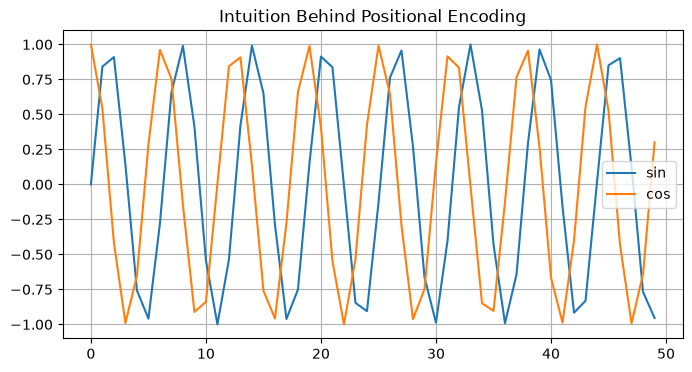

In [4]:
import numpy as np
import matplotlib.pyplot as plt

positions = np.arange(0, 50)

plt.figure(figsize=(8,4))

plt.plot(positions, np.sin(positions), label="sin")
plt.plot(positions, np.cos(positions), label="cos")

plt.title("Intuition Behind Positional Encoding")
plt.legend()
plt.grid()

plt.show()

## 🧩 Main Components

The Transformer consists of:

1. Tokenization
2. Embedding Layer
3. Positional Encoding
4. Self-Attention
5. Multi-Head Attention
6. Feed Forward Network
7. Residual Connection
8. Layer Normalization
9. Encoder
10. Decoder

We will build each component one by one.

## ✅ Advantages

- Parallel computation
- Faster training
- Handles long-range dependencies well
- Scales to very large datasets
- Foundation of modern LLMs

##  Remaining Question

We know the Transformer processes all words together.

But how does it decide which words are important?

For example:

"The animal didn't cross the street because it was tired."

When processing "it",

how does the model know to focus on "animal"?

The answer is **Self-Attention**.

## ✅ Summary

Today I learned:

- Why the Transformer was invented.
- Why sequential models were limiting.
- Why parallel processing is important.
- What positional encoding is.
- The high-level Transformer architecture.

## 🧠 Think Like a Researcher

Imagine you're a Google researcher in 2017.

You have removed RNNs completely.

Great!

But one question remains:

If every word is processed simultaneously...

How does each word know which other words to focus on?

This single question leads to the heart of the Transformer:

**Self-Attention.**